# Contentsquare User Behaviour Analysis

## Project Overview

This analysis examines user behaviour on an e-commerce storefront using data exported from Contentsquare.

The storefront was created as part of the project to collect real user interaction data. Contentsquare was connected to the website to capture information about user journeys, page views, engagement and navigation behaviour.

The analysis uses Python and Pandas to explore the exported data and identify potential user experience and conversion insights.

### Objectives

- Analyse user sessions and engagement
- Examine page views and page performance
- Understand user navigation journeys
- Identify potential drop-off points
- Analyse user engagement behaviour
- Create visualisations to communicate findings
- Develop practical UX and business recommendations

### Data Source

The data analysed in this notebook was exported from Contentsquare based on activity recorded on the project e-commerce storefront.

**Analysis tools:** Python, Pandas and Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
import os

print(os.listdir())

['.ipynb_checkpoints', '2026-08-13-journey-analysis.png', 'ContentsquareAnalysis.ipynb', 'Key Performance Metrics-08_13_2026-Contentsquare.xlsx', 'Overview template-08_13_2026-Contentsquare.xlsx']


In [4]:
import pandas as pd

for file in [
    "Key Performance Metrics-08_13_2026-Contentsquare.xlsx",
    "Overview template-08_13_2026-Contentsquare.xlsx"
]:
    print("\nFILE:", file)
    xls = pd.ExcelFile(file)
    print("Sheets:", xls.sheet_names)


FILE: Key Performance Metrics-08_13_2026-Contentsquare.xlsx
Sheets: ['Dashboard']

FILE: Overview template-08_13_2026-Contentsquare.xlsx
Sheets: ['Dashboard']


In [5]:
kpi_file = "Key Performance Metrics-08_13_2026-Contentsquare.xlsx"

kpi_raw = pd.read_excel(kpi_file, sheet_name="Dashboard", header=None)

print("Shape:", kpi_raw.shape)

display(kpi_raw.head(30))

Shape: (167, 3)


,0,1,2
0,Dashboard name,Key Performance Metrics,NaN
1,Export date,08/13/2026 15:47,NaN
2,NaN,NaN,NaN
3,Group,Performance,NaN
4,NaN,NaN,NaN
5,Widget name,Sessions,NaN
6,Analysis level,Site,NaN
7,Metric name,Number of sessions,NaN
8,Segment,All users,NaN
9,Device,All devices,NaN


In [6]:
# Extract key website KPIs

sessions = kpi_raw.loc[12, 1]
bounce_rate = kpi_raw.loc[22, 1]

print("Website Performance")
print("-------------------")
print("Total sessions:", sessions)
print("Bounce rate:", bounce_rate, "%")

Website Performance
-------------------
Total sessions: 3
Bounce rate: nan %


In [7]:
print(kpi_raw.to_string())

                                                0                                          1           2
0                                  Dashboard name                    Key Performance Metrics         NaN
1                                     Export date                           08/13/2026 15:47         NaN
2                                             NaN                                        NaN         NaN
3                                           Group                                Performance         NaN
4                                             NaN                                        NaN         NaN
5                                     Widget name                                   Sessions         NaN
6                                  Analysis level                                       Site         NaN
7                                     Metric name                         Number of sessions         NaN
8                                         Segment      

In [8]:
# Key website performance metrics

total_sessions = kpi_raw.loc[12, 1]
bounce_rate = kpi_raw.loc[21, 1]
views_per_session = kpi_raw.loc[112, 1]
session_time = kpi_raw.loc[103, 1]

print("Contentsquare Website Performance")
print("----------------------------------")
print("Total sessions:", total_sessions)
print("Bounce rate:", bounce_rate, "%")
print("Views per session:", views_per_session)
print("Average session time:", session_time)

Contentsquare Website Performance
----------------------------------
Total sessions: 3
Bounce rate: 33.33 %
Views per session: 24.67
Average session time: 756.53


In [9]:
# Extract daily session data

daily_sessions = kpi_raw.loc[42:48, [1, 2]].copy()

daily_sessions.columns = ["Sessions", "Date"]

daily_sessions = daily_sessions.dropna()
daily_sessions["Sessions"] = pd.to_numeric(daily_sessions["Sessions"])

display(daily_sessions)

,Sessions,Date
42,0,08/07/2026
43,0,08/08/2026
44,0,08/09/2026
45,0,08/10/2026
46,0,08/11/2026
47,2,08/12/2026
48,1,08/13/2026


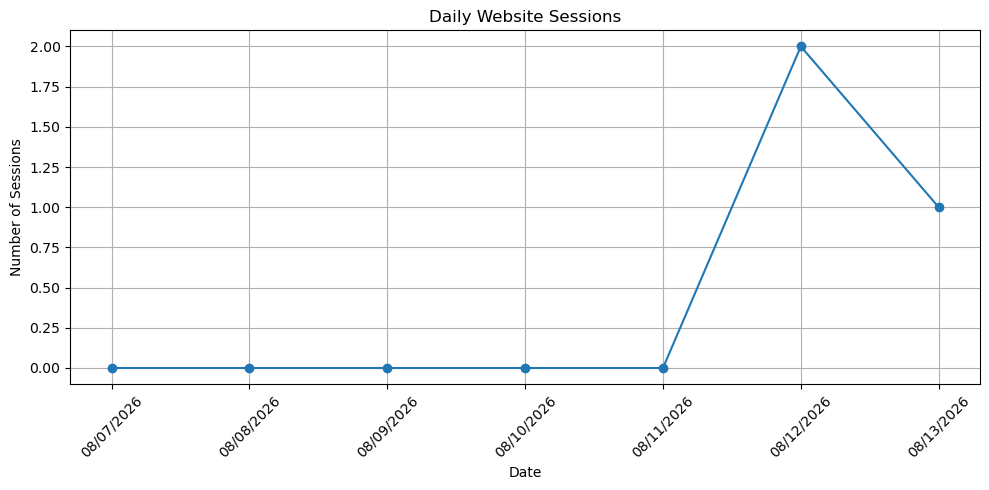

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_sessions["Date"],
    daily_sessions["Sessions"],
    marker="o"
)

plt.title("Daily Website Sessions")
plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Extract daily bounce rate

daily_bounce = kpi_raw.loc[58:64, [1, 2]].copy()

daily_bounce.columns = ["Bounce_Rate", "Date"]

daily_bounce = daily_bounce.dropna()
daily_bounce["Bounce_Rate"] = pd.to_numeric(daily_bounce["Bounce_Rate"])

display(daily_bounce)

,Bounce_Rate,Date
58,0,08/07/2026
59,0,08/08/2026
60,0,08/09/2026
61,0,08/10/2026
62,0,08/11/2026
63,50,08/12/2026
64,0,08/13/2026


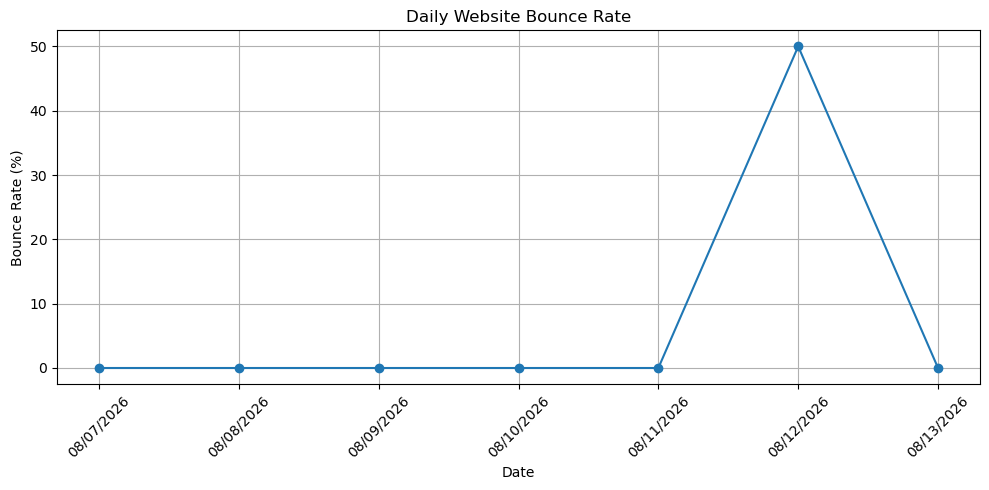

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_bounce["Date"],
    daily_bounce["Bounce_Rate"],
    marker="o"
)

plt.title("Daily Website Bounce Rate")
plt.xlabel("Date")
plt.ylabel("Bounce Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Device performance

device_sessions = kpi_raw.loc[32, 1]
device_bounce = kpi_raw.loc[75, 1]

print("Device Performance")
print("------------------")
print("Desktop sessions:", device_sessions)
print("Desktop bounce rate:", device_bounce, "%")

Device Performance
------------------
Desktop sessions: 3
Desktop bounce rate: 33.33 %


In [15]:
# Key website performance findings

peak_sessions = daily_sessions.loc[daily_sessions["Sessions"].idxmax()]
peak_bounce = daily_bounce.loc[daily_bounce["Bounce_Rate"].idxmax()]

print("Key Website Performance Findings")
print("---------------------------------")
print(f"Total sessions: {total_sessions}")
print(f"Overall bounce rate: {bounce_rate:.2f}%")
print(f"Views per session: {views_per_session:.2f}")
print(f"Average session time: {session_time:.2f} seconds")
print(f"Peak sessions: {int(peak_sessions['Sessions'])} on {peak_sessions['Date']}")
print(f"Peak bounce rate: {peak_bounce['Bounce_Rate']:.2f}% on {peak_bounce['Date']}")

Key Website Performance Findings
---------------------------------
Total sessions: 3
Overall bounce rate: 33.33%
Views per session: 24.67
Average session time: 756.53 seconds
Peak sessions: 2 on 08/12/2026
Peak bounce rate: 50.00% on 08/12/2026


## Key Findings

The Contentsquare data shows limited but useful website activity during the observation period.

- The website recorded 3 sessions during the reporting period.
- The overall bounce rate was 33.33%.
- Average views per session were 24.67.
- Average session time was approximately 12.6 minutes.
- The highest daily activity occurred on 12 August, with 2 sessions.
- The highest daily bounce rate was 50% on 12 August.
- All recorded sessions were from desktop devices.

### Interpretation

Due to the small number of recorded sessions, these results should be treated as directional rather than statistically representative. However, the data demonstrates how Contentsquare can be used to monitor website engagement, identify changes in traffic behaviour and support UX-focused analysis.